In [1]:
import pandas as pd
import numpy as np
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv('Covid.csv', parse_dates=[0], header=None, index_col=0, names=['Fecha','Contagios diarios','Contagios acumulados','C.A/100mil','C.D/100mil'])
df['weekday']=[x.weekday() for x in df.index]
df['month']=[x.month for x in df.index]
df.head()

,Contagios diarios,Contagios acumulados,C.A/100mil,C.D/100mil,weekday,month
Fecha,,,,,,
2020-03-16,68,297,0.053,0.23,0,3
2020-03-17,93,390,0.073,0.31,1,3
2020-03-18,102,492,0.080,0.38,2,3
2020-03-19,110,602,0.086,0.47,3,3
2020-03-20,100,702,0.078,0.55,4,3


In [2]:
df = df.dropna(subset = ['Contagios diarios'])
df = df.sample(frac=1).head(150)
Y = df['Contagios diarios']
X = df[['Contagios acumulados']]

In [3]:
df.columns

Index(['Contagios diarios', 'Contagios acumulados', 'C.A/100mil', 'C.D/100mil',
       'weekday', 'month'],
      dtype='object')

In [4]:
regr = linear_model.LinearRegression()
regr.fit(X,Y)

print('Coeficientes: ',regr.coef_)
Y_pred = regr.predict(X)
print('R cuadrado: ',r2_score(Y, Y_pred))

Coeficientes:  [0.01503038]
R cuadrado:  0.6622949110787641


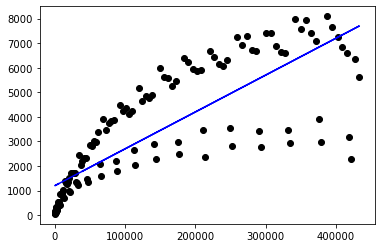

In [5]:
plt.scatter(X[1:200],Y[1:200],color = 'black')
plt.plot(X[1:200],Y_pred[1:200],color = 'blue')
plt.show()

In [6]:
X = df[['C.A/100mil','C.D/100mil']]

df['month'] = df['month'].apply(str)
df['weekday'] = df['weekday'].apply(str)

dummies = pd.get_dummies(data=df[['month','weekday']])
X = dummies.add(X,fill_value=0)

In [7]:
X.columns

Index(['C.A/100mil', 'C.D/100mil', 'month_3', 'month_4', 'month_5', 'month_6',
       'month_7', 'weekday_0', 'weekday_1', 'weekday_2', 'weekday_3',
       'weekday_4', 'weekday_5', 'weekday_6'],
      dtype='object')

In [8]:
regr = linear_model.LinearRegression()
regr.fit(X,Y)

#print('Coeficientes: ',regr.coef_)
Y_pred = regr.predict(X)
print('R cuadrado: ',r2_score(Y, Y_pred))

R cuadrado:  0.9999976828876654


In [9]:
X = X.add(df[['Contagios acumulados']],fill_value=0)

In [10]:
regr = linear_model.LinearRegression()
regr.fit(X,Y)

#print('Coeficientes: ',regr.coef_)
Y_pred = regr.predict(X)
print('R cuadrado: ',r2_score(Y, Y_pred))

R cuadrado:  0.9999976984146953
